In [14]:
import os
import re
import warnings
import pandas as pd
import numpy as np

from Bio import SeqIO
from scipy.stats import beta
from tqdm import tqdm
from typing import Dict, List

from StreamOutput import StreamOutput
from UtilityFunctions import parseCGmap, parseASM


class SetCytosineMethylation:
    '''
    prepare Cytosine methylation level database for read methylation state simulation
    :param str  ref_fasta   : path to the reference genome (.fasta/.fa/.fa.gz) [None]
    :param str  outdir      : path to the output directory [None]
    :param str  meth_db_path: path to the previous obj (.pkl) [None]
    :param str  cgmap_file  : path to the cgmap file (.CGmap/.CGmap.gz) [False]
    :param bool cgmap_pool  : whether to pool methylaiton levels and random draws from it [False]
    :param str  asm_file    : path to the allelic specific methylation (ASM) file [None]
    :param dict beta_params : dict of beta parameters for CG/CHG/CHH methylation values simulation
                              [{"CG": (0.5, 0.5), "CHG": (0.01, 0.05), "CHH":(0.01, 0.05)}]
    :param bool collect_ch  : whether to collect/simulate the CHG/CHH sites [False]
    :param bool overwrite_db: whether to overwrite the meth_db if it already exists [True]
    :param int  seed        : seed for random methylation generation
    :param bool verbose     : whether to output processing details [True]
    :rtype None

    :var np.array meth_arr  : nx5 numpy array: context, flag, meth_avg, meth_ref, meth_alt
                              - flag: 0 from dist or pool, 1 from CGmap, 2 from ASM, -1 unintialized
    :var pd.Series pos_map  : pd.Series of length n
                              - index is genome coordinate, value is row idx of meth_arr
    '''


    def __init__(self, ref_fasta: str = None, outdir: str = None,
                 meth_db_path: str = None, cgmap_file: str = None, cgmap_pool: bool = False,
                 beta_params: dict = {"CG": (0.5, 0.5), "CHG": (0.01, 0.05), "CHH":(0.01, 0.05)},
                 asm_file: str = None, update_boundary: bool = False,
                 collect_ch: bool = True, overwrite_db: bool = False,
                 seed: int = None, verbose: bool = False):

        self.ref_fasta   = ref_fasta
        self.outdir      = outdir
        self.meth_db_path= meth_db_path
        self.cgmap_file  = cgmap_file
        self.cgmap_pool  = cgmap_pool
        self.beta_params = beta_params
        self.asm_file    = asm_file
        self.asm_sim     = True if asm_file else False
        self.collect_ch  = collect_ch
        self.overwrite_db= overwrite_db
        self.seed        = seed
        self.verbose     = verbose
        self.meth_arr    = None
        self.pos_map     = None

        self.update_boundary   = update_boundary and not self.asm_sim
        self.context_dict      = {1:'CG', 3:'CHG', 7:'CHH', 9:'CG', 11:'CHG', 15:'CHH'}
        self.base_context_dict = {'C': {'CG':1, 'CHG':3, 'CHH':7}, 'G': {'CG':9, 'CHG':11, 'CHH':15}}
        self.base_context_table= {'C': np.array([[7,3],  [1,1]]),  'G': np.array([[15,11],[9,9]])}

        # check existence
        if not os.path.exists(ref_fasta):
            raise ValueError('Cannot find the reference genome, please check!')
        if not outdir:
            raise ValueError('Please specify the output directory!')
        if self.asm_sim and not os.path.exists(asm_file):
            raise ValueError('Please specify allelic specific methylation file correctly for ASM simulation!')

        self.meth_db = StreamOutput(outdir=self.outdir, overwrite_db=self.overwrite_db)
        self.meth_db.check_outdir()
        self.ref_dict= SeqIO.to_dict(SeqIO.parse(ref_fasta, "fasta"))
        self.genome_len = sum([len(seq) for _, seq in self.ref_dict.items()])

        # initiate
        if meth_db_path:
            self.check_meth_db()
        else:
            self.create_meth_db()


    def check_meth_db(self):
        '''if use previous meth_db object, check if they align'''
        contig_id_list = self.ref_dict.keys()
        for contig_id in contig_id_list:
            contig_profile = self.meth_db.load_contig(contig_id, values=True)
            self.init_meth_db(contig_id)
            not_comp_sites = self.pos_map.index().difference(contig_profile[0].index())
            if len(not_comp_sites):
                print(f'{contig_id}: sites in the meth_db is not the same as the reference')


    def create_meth_db(self):
        '''parse the fasta, CGmap, ASM file into pickle for later simulation'''
        contig_id_list = self.ref_dict.keys()
        for contig_id in contig_id_list:
            self.current_contig = contig_id
            self.init_meth_db(contig_id)
            self.fill_cgmap(contig_id)
            self.fill_asm(contig_id)
            self.fill_dist()
            if self.verbose:
                print(f"Processed {self.pos_map.shape[0]} sites from contig {self.current_contig}")
            # the 3rd item: 1 for boundary updated by variants, 0 for not updated
            self.meth_db.output_contig(contig_id, [self.pos_map, self.meth_arr, 0], is_variant=False)


    def init_meth_db(self, contig_id):
        '''initialize data object using fasta sequence'''
        seq = self.ref_dict[contig_id].seq.upper()
        seq_len = len(seq)
        idx = 0

        if self.verbose:
            print(f"\n[Initiating the methylaiton database] for {self.current_contig}...")
        if self.collect_ch:
            count_c = seq.count("C")
            count_g = seq.count("G")
            arr_size= count_c + count_g
            self.meth_arr = np.full((arr_size, 5), fill_value=np.NaN, dtype=np.float16)
            self.meth_arr[:,1] = -1 # flag, record uninitialized sites
            self.pos_map  = pd.Series(0, index=range(arr_size), dtype=np.uint32)

            for pos, base in tqdm(enumerate(seq), disable = not self.verbose):
                if base not in {"C", "G"}:
                    continue
                if pos<2 or pos>=(seq_len-3):
                    base_d1 = base_d2 = 0
                else:
                    updown  = 1 if base == "C" else -1
                    base_d1 = seq[pos+1*updown]
                    base_d2 = seq[pos+2*updown]
                # C:{10, 11}: 1, {01}: 3, {00}: 7; G: {10, 11}: 9, {01}: 11, {00}: 15
                self.meth_arr[idx, 0] = self.get_cg_context(base, base_d1, base_d2) # context
                self.pos_map[idx] = pos
                idx += 1
        else:
            count_c = count_g = seq.count("CG")
            arr_size= count_c + count_g
            self.meth_arr= np.full((arr_size, 5), fill_value=np.NaN, dtype=np.float16)
            self.meth_arr[:,1]= -1
            self.pos_map = pd.Series(0, index=range(arr_size), dtype=np.uint32)

            for cg_match in tqdm(re.finditer("CG", str(seq)), disable = not self.verbose):
                pos = cg_match.start()
                self.meth_arr[idx,  0] = [pos,  1]
                self.meth_arr[idx+1,0] = [pos+1,9]
                self.pos_map[idx]  = pos
                self.pos_map[idx+1]= pos+1
                idx += 2
        self.pos_map = pd.Series(self.pos_map.index.values, index=self.pos_map)


    def fill_cgmap(self, contig_id):
        '''fill sites in the cgmap file'''
        if not self.cgmap_file:
            return None

        if self.verbose:
            print(f"Filling CGmap for {self.current_contig}... ", end="")
        if self.cgmap_pool:
            meth_level_pool = self.get_cgmap_pool(contig_id=None)
            idx_cg  = np.where(np.bitwise_and(self.meth_arr[:,0].astype(np.int16), 0x7)==1)
            np.random.seed(self.seed)
            self.meth_arr[idx_cg, 2] = np.random.choice(meth_level_pool[0], size=np.sum(idx_cg))

            if self.collect_ch:
                idx_chg = np.where(np.bitwise_and(self.meth_arr[:,0].astype(np.int16), 0x7)==3)
                idx_chh = np.where(np.bitwise_and(self.meth_arr[:,0].astype(np.int16), 0x7)==7)
                np.random.seed(self.seed)
                self.meth_arr[idx_chg,2] = np.random.choice(meth_level_pool[1], size=np.sum(idx_chg))
                np.random.seed(self.seed)
                self.meth_arr[idx_chh,2] = np.random.choice(meth_level_pool[2], size=np.sum(idx_chh))
            return None

        num_cgmap_pos, num_404_pos = [0,0]  # counting
        for line in parseCGmap(self.cgmap_file, contig_id, collect_ch = self.collect_ch):
            num_cgmap_pos += 1
            _, base, pos, context, meth_level = line
            try:
                arr_idx = self.pos_map[int(pos) - 1] # CGmap file is 1-based coordinate
            except IndexError:
                num_404_pos += 1
            else:
                if (self.meth_arr[arr_idx, 0] != self.base_context_dict[base][context]):
                    num_404_pos +=1
                    continue
                self.meth_arr[arr_idx, 1:3] = [1, float(meth_level)]

        if self.verbose:
            if num_cgmap_pos:
                ratio_404 = round(num_404_pos / num_cgmap_pos, 4)
                ### also print what context
                print(f"{num_cgmap_pos} sites found in CGmap file," +
                    f"among them {num_404_pos} sites ({ratio_404 * 100}%) are not compatible...")
                if ratio_404 >=0.5:
                    warnings.warn("[WARNING]: More than half sites in CGmap file cannot be found in the reference fasta\n" +
                                  "Potential reason: the CGmap does not share the same coordinates with fasta, please check!")
            else:
                print(f"No sites found in CGmap file for {self.current_contig}, skip...")
        return None


    def fill_asm(self, contig_id):
        '''fill the allelic specific sites'''
        if not self.asm_sim:
            return None

        if self.verbose:
            print(f"Filling ASM for {self.current_contig}... ", end="")
        num_asm_pos, num_404_pos = [0,0] # counting
        for line in parseASM(self.asm_file, contig_id, collect_ch = self.collect_ch):
            _, base, pos, context, tot_meth, ref_meth, alt_meth = line
            num_asm_pos += 1
            try:
                arr_idx = self.pos_map[int(pos) - 1]
            except IndexError:
                num_404_pos += 1
            else:
                if (self.meth_arr[arr_idx, 0] != self.base_context_dict[base][context]):
                    num_404_pos +=1
                    continue
                self.meth_arr[arr_idx, 1:4] = [2, tot_meth, ref_meth, alt_meth]

        if self.verbose:
            if num_asm_pos:
                ratio_404 = round(num_404_pos / num_asm_pos, 4)
                print(f"{num_asm_pos} sites found in CGmap file, " +
                    f"among them {num_404_pos} sites ({ratio_404 * 100}%) are not compatible...")
                if ratio_404 >=0.5:
                    warnings.warn("[WARNING]: More than half sites in ASM file cannot be found in the reference fasta\n" +
                                  "Potential reason: the CGmap does not share the same coordinates with fasta, please check!")
            else:
                print(f"No sites found in ASM file for {self.current_contig}, skip...")
        return None


    def fill_dist(self):
        '''fill in from beta distribution'''

        if self.verbose:
            print(f"Filling with beta distribution for {self.current_contig}...")
        idx_nan = np.isnan(self.meth_arr[:,2]) # hold for each element
        idx_ctx = np.bitwise_and(self.meth_arr[:,0].astype(np.int16), 0x7) # hold for each element
        idx_nan_cg  = np.where((idx_ctx == 1) & idx_nan)[0] # hold for index

        num_idx_nan_cg = len(idx_nan_cg)

        if num_idx_nan_cg:
            self.meth_arr[idx_nan_cg, 2] = self.simu_beta_dist(context="CG", size=num_idx_nan_cg)

        if self.collect_ch:
            idx_nan_chg = np.where((idx_ctx == 3) & idx_nan)[0]
            idx_nan_chh = np.where((idx_ctx == 7) & idx_nan)[0]

            num_idx_nan_chg = len(idx_nan_chg)
            num_idx_nan_chh = len(idx_nan_chh)
            if num_idx_nan_chg:
                self.meth_arr[idx_nan_chg, 2]= self.simu_beta_dist(context="CHG", size=num_idx_nan_chg)
            if num_idx_nan_chh:
                self.meth_arr[idx_nan_chh, 2]= self.simu_beta_dist(context="CHH", size=num_idx_nan_chh)

        self.meth_arr[idx_nan, 1] = 0
        self.meth_arr[idx_nan, 3] = self.meth_arr[idx_nan, 2]
        self.meth_arr[idx_nan, 4] = self.meth_arr[idx_nan, 2]


    def set_var_meth(self, contig_id, sim_data, update_boundary=True) -> Dict[str, List]:
        '''set random methylation due to variants are random, update the meth_arr on the boundary'''
        if not sim_data: # can have no variant
            return None
        self.update_boundary = update_boundary
        if update_boundary:
            self.pos_map, self.meth_arr, _ = self.meth_db.load_contig(contig_id)
        var_meth_dict = {}

        seq = self.ref_dict[contig_id].seq.upper()
        seq_len = len(seq)
        for pos, variant_info in sim_data.items():
            if pos<2 or pos>(seq_len-2):
                continue
            if variant_info['indel'] == -1:  # deletion starts at pos
                offset = variant_info['offset']
                local_seq = f'{seq[(pos-2):(pos)]}{seq[(pos+offset):(pos+offset+2)]}'
                pos_list  = [pos-2, pos-1, pos+offset, pos+offset+1]
                self.handle_boundary(pos_list, local_seq)
                continue
            elif variant_info['indel'] == 1:  # insertion starts at pos
                offset = variant_info['offset']
                local_seq = f'{seq[(pos-2):(pos)]}{variant_info["alt"]}{seq[(pos):(pos+2)]}'
                pos_list  = [pos-2, pos-1, pos, pos+1]
                self.handle_boundary(pos_list, local_seq)

                ins_meth_arr = np.zeros(offset)
                ins_ctx_arr  = np.zeros(offset)
                for ins_idx, base in enumerate(variant_info['alt']):
                    if base not in {'C', 'G'}:
                        continue
                    updown  = 1 if base == "C" else -1  # whether to go upstream or downstream
                    base_d1 = local_seq[1*updown+ins_idx+2]
                    base_d2 = local_seq[2*updown+ins_idx+2]
                    context = self.get_cg_context(base, base_d1, base_d2)
                    ins_meth_arr[ins_idx]= self.simu_beta_dist(context=context)[0] # base,3,context
                    ins_ctx_arr[ins_idx] = context

                if np.any(ins_ctx_arr):
                    variant_info['meth'] = ins_meth_arr
                    variant_info['ctx']  = ins_ctx_arr
                    var_meth_dict[pos]   = (ins_meth_arr, ins_ctx_arr)
            else: # substitution
                base = variant_info['alt']
                local_seq = f'{seq[(pos-2):pos]}{variant_info["alt"]}{seq[(pos+1):(pos+3)]}'
                pos_list  = [pos-2, pos-1, pos+1, pos+2]
                self.handle_boundary(pos_list, local_seq)

                if base not in {'C', 'G'}:
                    continue
                updown  = 1 if base == "C" else -1
                base_d1 = local_seq[1*updown+2]
                base_d2 = local_seq[2*updown+2]
                context = self.get_cg_context(base, base_d1, base_d2)
                snp_meth= self.simu_beta_dist(context=context)[0]
                variant_info['meth'] = snp_meth
                variant_info['ctx']  = context
                var_meth_dict[pos]   = (snp_meth, context)
            sim_data[pos] = variant_info
        self.meth_db.output_contig(contig_id, sim_data, is_variant=True)
        if self.update_boundary:
            self.meth_db.output_contig(contig_id, [self.pos_map, self.meth_arr, 1], is_variant=False)
        return var_meth_dict


    def simu_beta_dist(self, context = "CG", size = 1):
        '''output the values accordig to the context using beta distribution'''
        if isinstance(context, int):
            context = self.context_dict[context]
        return beta.rvs(a=self.beta_params[context][0],
                        b=self.beta_params[context][1],
                        size=size, random_state=self.seed).astype(np.float16)


    def get_cgmap_pool(self, contig_id):
        '''get the pool of cgmaps, return a list of size 3'''
        ctx_idx_dict = {'CG':1, 'CHG':2, 'CHH':3}
        meth_level_pool = [[],[],[]]
        for line in parseCGmap(self.cgmap_file, contig_id, collect_ch = self.collect_ch):
            _, _,  _, context, meth_level = line
            meth_level_pool[ctx_idx_dict[context]].append(float(meth_level))
        return meth_level_pool


    def estimate_beta_params(self, context = None):
        '''estimate the beta parameters for each context'''
        ctx_idx_dict = {'CG':1, 'CHG':2, 'CHH':3}
        idx_ctx_dict = {v: k for k, v in ctx_idx_dict.items()}
        meth_level_pool = self.get_cgmap_pool(contig_id=None)
        beta_param_estimate = {}

        if context:
            idx = ctx_idx_dict[context]
            meth_list = meth_level_pool[idx]
            a, b, _, _ = beta.fit(meth_list)
            beta_param_estimate[context] = (a, b)
        else:
            for idx, meth_list in enumerate(meth_level_pool):
                context = idx_ctx_dict[idx]
                a, b, _, _ = beta.fit(meth_list)
                beta_param_estimate[context] = (a, b)
        return beta_param_estimate


    def get_cg_context(self, base, base_d1, base_d2):
        '''input the base and surrounding, output context'''
        if base == "C":
            flag_d1 = int(base_d1 == "G")
            flag_d2 = int(base_d2 == "G")
        elif base == "G":
            flag_d1 = int(base_d1 == "C")
            flag_d2 = int(base_d2 == "C")
        else:
            return None
        return self.base_context_table[base][flag_d1, flag_d2]


    def handle_boundary(self, pos_list, local_seq):
        '''accomandate the boundary of the mutations'''
        if self.update_boundary:
            ptr_list = [0, 1, -2, -1]
            assert len(pos_list) == 4 and len(local_seq) >= 4
            for idx, ptr in enumerate(ptr_list):
                base = local_seq[ptr]
                if ptr >= 0 and base == "C":
                    base_d1 = local_seq[ptr+1]
                    base_d2 = local_seq[ptr+2]
                elif ptr <0 and base == "G":
                    base_d1 = local_seq[ptr-1]
                    base_d2 = local_seq[ptr-2]
                else:
                    continue
                context     = self.get_cg_context(base, base_d1, base_d2)
                change_pos  = pos_list[idx]
                self.meth_arr[self.pos_map[change_pos], 4] = self.simu_beta_dist(context=context)[0]


# test random

In [15]:
meth_db = SetCytosineMethylation(ref_fasta="/home/wbguo/iproject/BSReadSim/test/ref/BSB_test.fa", 
                                 outdir="/home/wbguo/iproject/BSReadSim/test/outdir/",
                                 overwrite_db=True)

In [16]:
meth_db = SetCytosineMethylation(ref_fasta="/home/wbguo/iproject/BSReadSim/test/ref/BSB_test.fa", 
                                 outdir="/home/wbguo/iproject/BSReadSim/test/outdir/",
                                 overwrite_db=True, verbose=True)


[Initiating the methylaiton database] for chr10...


423500it [00:02, 156457.26it/s]


Filling with beta distribution for chr10...
Processed 187408 sites from contig chr10

[Initiating the methylaiton database] for chr11...


424000it [00:02, 155688.34it/s]


Filling with beta distribution for chr11...
Processed 187844 sites from contig chr11

[Initiating the methylaiton database] for chr12...


...

Filling with beta distribution for chr13...
Processed 142075 sites from contig chr13

[Initiating the methylaiton database] for chr14...


351250it [00:02, 157995.10it/s]


Filling with beta distribution for chr14...
Processed 154158 sites from contig chr14

[Initiating the methylaiton database] for chr15...


5000it [00:00, 145473.92it/s]

Filling with beta distribution for chr15...
Processed 2252 sites from contig chr15


In [17]:
meth_db.pos_map[meth_db.pos_map == 32]

76    32
dtype: int64

In [18]:
meth_db.meth_arr[1:40, ]

array([[1.500e+01, 0.000e+00, 2.411e-01, 2.411e-01, 2.411e-01],
       [7.000e+00, 0.000e+00, 5.364e-07, 5.364e-07, 5.364e-07],
       [7.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [7.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [1.500e+01, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [1.500e+01, 0.000e+00, 1.000e+00, 1.000e+00, 1.000e+00],
       [1.500e+01, 0.000e+00, 5.960e-08, 5.960e-08, 5.960e-08],
       [7.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 1.000e+00],
       [7.000e+00, 0.000e+00, 6.982e-01, 6.982e-01, 6.982e-01],
       [7.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 1.000e+00],
       [3.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 1.000e+00],
       [1.100e+01, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [1.500e+01, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [1.500e+01, 0.000e+00, 3.558e-05, 3.558e-05, 3.558e-05],
       [3.000e+00, 0.000e+00, 9.414e-01, 9.414e-01, 9.414e-01],
       [1.100e+01, 0.000e+00, 2.271e-05,

In [19]:
meth_db.meth_arr[2]

array([7.0e+00, 0.0e+00, 5.4e-07, 5.4e-07, 5.4e-07], dtype=float16)

In [20]:
pos_map, meth_arr, _ =  meth_db.meth_db.load_contig("chr10")

In [21]:
from pympler import asizeof
print(asizeof.asizeof(meth_db))

2070656


(array([146698.,   2088.,   1524.,   1289.,   1208.,   1225.,   1314.,
          1484.,   1946.,  28632.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ],
       dtype=float16),
 <BarContainer object of 10 artists>)

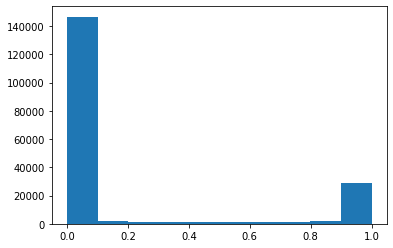

In [22]:
import matplotlib.pyplot as plt
plt.hist(meth_arr[:,2])

(array([1055.,  462.,  392.,  307.,  321.,  331.,  344.,  367.,  453.,
        1081.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ],
       dtype=float16),
 <BarContainer object of 10 artists>)

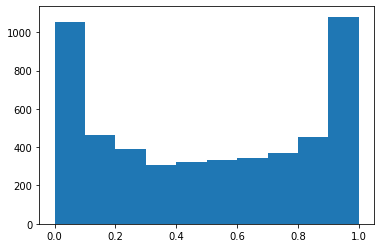

In [23]:
plt.hist(meth_arr[meth_arr[:,0] == 1, 2])

(array([16923.,   133.,    80.,    72.,    64.,    58.,    65.,    76.,
          101.,  3075.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ],
       dtype=float16),
 <BarContainer object of 10 artists>)

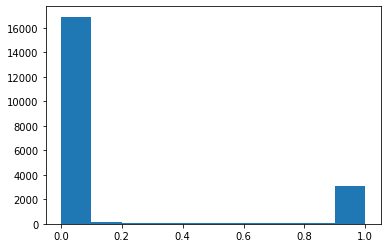

In [24]:
plt.hist(meth_arr[meth_arr[:,0] == 3,2])

(array([54953.,   444.,   310.,   236.,   212.,   208.,   244.,   257.,
          376., 10087.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ],
       dtype=float16),
 <BarContainer object of 10 artists>)

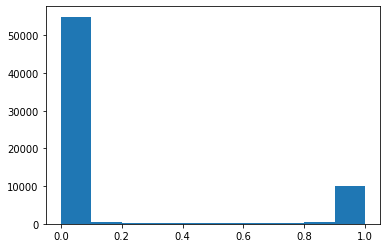

In [25]:
plt.hist(meth_arr[meth_arr[:,0] == 7,2])

# Test CGmap

In [26]:
meth_db = SetCytosineMethylation(ref_fasta="/home/wbguo/iproject/BSReadSim/test/ref/BSB_test.fa", 
                                 outdir="/home/wbguo/iproject/BSReadSim/test/outdir/",
                                 cgmap_file="/home/wbguo/iproject/BSReadSim/test/cgmap/sim.CGmap.gz",
                                 overwrite_db=True, verbose = True)


[Initiating the methylaiton database] for chr10...


423500it [00:02, 154587.65it/s]


Filling CGmap for chr10... 99453 sites found in CGmap file,among them 0 sites (0.0%) are not compatible...
Filling with beta distribution for chr10...
Processed 187408 sites from contig chr10

[Initiating the methylaiton database] for chr11...


424000it [00:02, 153291.53it/s]


Filling CGmap for chr11... 100584 sites found in CGmap file,among them 0 sites (0.0%) are not compatible...
Filling with beta distribution for chr11...
Processed 187844 sites from contig chr11

[Initiating the methylaiton database] for chr12...


...

351250it [00:02, 156859.72it/s]


Filling CGmap for chr14... 82954 sites found in CGmap file,among them 0 sites (0.0%) are not compatible...
Filling with beta distribution for chr14...
Processed 154158 sites from contig chr14

[Initiating the methylaiton database] for chr15...


5000it [00:00, 141384.21it/s]

Filling CGmap for chr15... 

No sites found in CGmap file, skip...
Filling with beta distribution for chr15...
Processed 2252 sites from contig chr15


# Test ASM & CGmap

# test CGmap for chr21

In [ ]:
meth_db = SetCytosineMethylation(ref_fasta="/home/wbguo/iproject/BSReadSim/test/ref/chr21.fa", 
                                 outdir="/home/wbguo/iproject/BSReadSim/test/outdir/",
                                 cgmap_file="/home/wbguo/iproject/BSReadSim/test/cgmap/ERR2359938.CGmap.gz",
                                 overwrite_db=True, verbose = True)

In [ ]:
print(asizeof.asizeof(meth_db))

In [ ]:
meth_db.meth_arr.shape

# test ASM

In [ ]:
meth_db = SetCytosineMethylation(ref_fasta="/home/wbguo/iproject/BSReadSim/test/ref/chr21.fa", 
                                 outdir="/home/wbguo/iproject/BSReadSim/test/outdir/",
                                 cgmap_file="/home/wbguo/iproject/BSReadSim/test/cgmap/ERR2359938.CGmap.gz",
                                 asm_file = "/home/wbguo/iproject/BSReadSim/test/asm/ERR2359938.asm.gz"
                                 overwrite_db=True, verbose = True)

# test time and mem

In [ ]:
%timeit myDict[np.random.randint(0, 10**6)]  # 5.81 us, 41943136 byte
%timeit myArr[np.random.randint(0, 10**6),:] # 6.27 us, 10000120 byte
%timeit np.where(myArr[:,0] == np.random.randint(0, 10**6)) # 4.21 ms
# pos_map = {int(i):int(i) for i in range(arr_size)}  
%timeit myArr[pos_map[np.random.randint(0, 10**6)],:] # 6.72 µs,   41943136 byte
# pd_series = pd.Series(range(arr_size), dtype = np.uint32) 
%timeit myArr[pd_series[np.random.randint(0, 10**6)],:] # 13.8 µs, 4000144 byte
## have not checked 10**7, it's generally very long

In [28]:
# column context, row cigar
table =np.array([['M', 'c', 'C', 'b',  'B', 'a', 'A', '-',  '-', 'c', 'C', 'b',  'B', 'a', 'A', '-'], # match
                 ['x', 'x', 'X', 'x',  'X', 'x', 'X', '-',  '-', 'x', 'X', 'x',  'X', 'x', 'X', '-'], # snp
                 ['-', '-', '-', '-',  '-', '-', '-', '-',  '-', '-', '-', '-',  '-', '-', '-', '-'], # empty
                 ['M', 'i', 'I', 'i',  'I', 'i', 'I', '-',  '-', 'i', 'I', 'i',  'I', 'i', 'I', '-'], # insert
                 ['-', '-', '-', '-',  '-', '-', '-', '-',  '-', '-', '-', '-',  '-', '-', '-', '-'], # empty
                 ['-', '#', '-', '#',  '-', '#', '-', '-',  '-', '#', '-', '#',  '-', '#', '-', '-']])# convert

In [29]:
import sys
sys.getsizeof(table)

504

In [30]:
table

array([['M', 'c', 'C', 'b', 'B', 'a', 'A', '-', '-', 'c', 'C', 'b', 'B',
        'a', 'A', '-'],
       ['x', 'x', 'X', 'x', 'X', 'x', 'X', '-', '-', 'x', 'X', 'x', 'X',
        'x', 'X', '-'],
       ['-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-',
        '-', '-', '-'],
       ['M', 'i', 'I', 'i', 'I', 'i', 'I', '-', '-', 'i', 'I', 'i', 'I',
        'i', 'I', '-'],
       ['-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-',
        '-', '-', '-'],
       ['-', '#', '-', '#', '-', '#', '-', '-', '-', '#', '-', '#', '-',
        '#', '-', '-']], dtype='<U1')